# PDE vs CosmoTherm Spectral Comparison

Generates `pde_cosmotherm_comparison.pdf` (Figure 3 in paper).

Six panels (2x3) comparing intensity distortions from single-burst energy injection at representative redshifts.

In [1]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

from spectroxide import (
    run_sweep, solve, run_single,
    greens_function, mu_shape, y_shape, g_bb,
    j_mu, j_y, j_bb_star,
    KAPPA_C,
    delta_n_to_delta_I,
    apply_style, C, SINGLE_COL, DOUBLE_COL,
)
from spectroxide.cosmotherm import (
    load_greens_database,
    convolve_cosmotherm_gf, strip_gbb,
    ct_heating_rate_swave, ct_heating_rate_pwave, ct_heating_rate_decay,
    cosmotherm_gf_distortion, reconstruct_full_gf,
    cosmotherm_gf_to_delta_n,
)
from spectroxide.greens import COSMOTHERM_GF_COSMO
from spectroxide.plot_params import (
    LW, LW_THIN, LW_THICK, LW_AXIS,
    ANNOT_SIZE, RESID_BAND, RESID_BAND_ALPHA, RESID_MASK_FRAC,
)


apply_style()

delta_rho = 1e-5

def _get(d, key, fallback_key=None):
    if key in d:
        return d[key]
    if fallback_key and fallback_key in d:
        return d[fallback_key]
    return 0.0


## Load CosmoTherm GF database and run PDE

In [ ]:
try:
    z_h_ct, x_ct, g_th_ct = load_greens_database()
    has_cosmotherm = True
    print(f"CosmoTherm GF database loaded: {len(z_h_ct)} redshifts, {len(x_ct)} frequencies")
except FileNotFoundError:
    has_cosmotherm = False
    print("CosmoTherm GF database not found")
if has_cosmotherm:
    # Load with metadata for temperature shift reconstruction
    z_h_ct_m, x_ct_m, g_th_ct_m, meta = load_greens_database(include_metadata=True)
    g_th_full = reconstruct_full_gf(x_ct_m, g_th_ct_m, z_h_ct_m, meta, apply_exp=True)

    # 6 panels (2 rows x 3 cols): y-era through thermalization
    target_zh = [3e3, 1e4, 5e4, 2e5, 5e5, 2e6]
    era_labels = [
        r"$y$-era", r"$y$-era (late)", r"$y$--$\mu$ transition",
        r"$\mu$-era", r"$\mu$-era (deep)", "near thermalization",
    ]

    def _fmt_zh(z):
        """Format z_h as nice LaTeX scientific notation."""
        exp = int(np.floor(np.log10(z)))
        coeff = z / 10**exp
        if abs(coeff - 1.0) < 0.01:
            return rf"$z_h = 10^{exp}$"
        elif abs(coeff - round(coeff)) < 0.01:
            return rf"$z_h = {int(round(coeff))} \times 10^{exp}$"
        else:
            return rf"$z_h = {coeff:.1f} \times 10^{exp}$"

    ct_matches = []
    for zt in target_zh:
        idx = np.argmin(np.abs(z_h_ct_m - zt))
        ct_matches.append((z_h_ct_m[idx], idx))
    test_zh = [zh for zh, _ in ct_matches]
    ct_col_indices = [ci for _, ci in ct_matches]

    print("Matched CosmoTherm z_h values:")
    for zt, zh_exact, ci in zip(target_zh, test_zh, ct_col_indices):
        print(f"  Target {zt:.0e} -> CT z_h = {zh_exact:.2f} (col {ci})")

    # Run PDE at exact CT z_h values
    print("\nRunning PDE at matched z_h values...")
    pde_ct_results = {}
    low_z = [zh for zh in test_zh if zh < 1e6]
    high_z = [zh for zh in test_zh if zh >= 1e6]

    if low_z:
        sw_low = run_sweep(delta_rho=delta_rho, z_injections=low_z,
                           n_points=2000, production_grid=True, timeout=1200)
        for r in sw_low["results"]:
            zh_r = _get(r, "z_h", "z_injection")
            best = min(low_z, key=lambda z: abs(z - zh_r))
            pde_ct_results[best] = r

    for zh in high_z:
        print(f"  High-z PDE: z_h={zh:.1e}, n_points=4000")
        sw_hi = solve(delta_rho=delta_rho,
                      injection={"type": "single-burst", "z_h": zh},
                      z_start=max(zh * 2.5, 3e6), z_end=500,
                      n_points=4000, production_grid=True, timeout=1200)
        # Wrap SolverResult in a dict matching the run_sweep result shape
        pde_ct_results[zh] = {"x": sw_hi.x.tolist(), "delta_n": sw_hi.delta_n.tolist(),
                              "pde_mu": sw_hi.mu, "pde_y": sw_hi.y,
                              "drho": sw_hi.delta_rho_over_rho, "z_h": sw_hi.z_h}

    x_query = np.linspace(0.3, 15, 400)


## Figure

/tmp/ipykernel_5948/1375039232.py:52: UserWarning: z_h=2931: Low-redshift injection (z < 5000). J_Compton < 0.01 here: Comptonization is highly inefficient, so heat injection produces negligible mu/y distortions. Use greens_function_with_cosmo or the cosmo-aware run_single (from spectroxide import greens_function_with_cosmo, run_single) for physically correct results; the basic Green's function overestimates y by orders of magnitude in this regime.
  dn_gf = greens_function(x_query, zh)


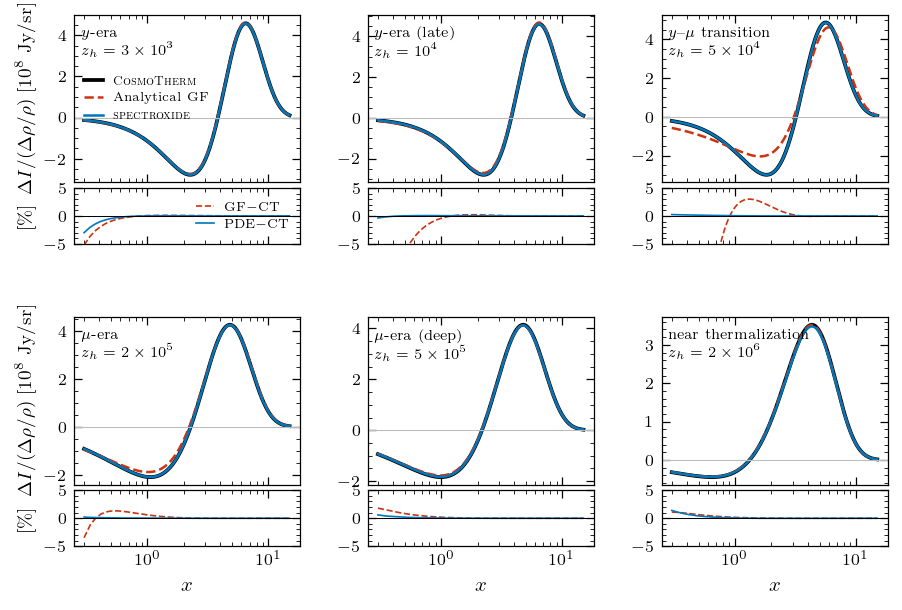


--- CosmoTherm comparison RMS errors ---
         z_h                   Era      RMS%
--------------------------------------------------
     2931.14               $y$-era      0.2%
    10018.26        $y$-era (late)      0.0%
    49581.63  $y$--$\mu$ transition      0.0%
   201687.62             $\mu$-era      0.0%
   500000.00      $\mu$-era (deep)      0.0%
  1944077.59   near thermalization      0.1%


In [3]:
# ================================================================
# Paper Figure: PDE vs CosmoTherm comparison
# 2 rows x 3 cols, each with spectrum + residual
# Plots intensity Delta I_nu [Jy/sr] vs frequency nu [GHz]
# Data normalized by 1e8 and factor folded into y-label so the
# offset text does not clip into the residual panel above.
#
# Layout: outer GridSpec (2 row blocks) with generous hspace
# between blocks; inner GridSpec (spectrum + residual) with tight
# hspace within each block. This prevents the residual [%] label
# from colliding with the spectrum y-label of the row below.
# ================================================================
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

n_cols = 3
n_rows = 2
INT_SCALE = 1e8  # fold sci-notation offset into y-label

fig = plt.figure(figsize=(DOUBLE_COL, 4.6))
outer = GridSpec(2, 1, figure=fig, hspace=0.32)

all_axes = []  # all_axes[block][sub_row][col]
for i_block in range(n_rows):
    inner = GridSpecFromSubplotSpec(
        2, n_cols, subplot_spec=outer[i_block],
        height_ratios=[3, 1], hspace=0.05, wspace=0.30,
    )
    block_axes = [[None] * n_cols, [None] * n_cols]
    for col in range(n_cols):
        ax_top = fig.add_subplot(inner[0, col])
        ax_bot = fig.add_subplot(inner[1, col], sharex=ax_top)
        ax_top.tick_params(labelbottom=False)
        # Hide x-tick labels on top-block residuals; only the bottom
        # block carries the x-axis labels (matches single-gridspec look).
        if i_block == 0:
            ax_bot.tick_params(labelbottom=False)
        block_axes[0][col] = ax_top
        block_axes[1][col] = ax_bot
    all_axes.append(block_axes)

for i_panel, (zh, ct_col, era) in enumerate(zip(test_zh, ct_col_indices, era_labels)):
    row = i_panel // n_cols
    col = i_panel % n_cols
    ax = all_axes[row][0][col]   # spectrum
    ax_b = all_axes[row][1][col]  # residual

    # CosmoTherm: full (G_bb restored)
    gf_full = np.interp(x_query, x_ct_m, g_th_full[:, ct_col])
    dn_ct_full = cosmotherm_gf_to_delta_n(x_query, gf_full)

    # Analytical GF
    dn_gf = greens_function(x_query, zh)

    # PDE
    r_pde = pde_ct_results.get(zh)
    dn_pde = None
    if r_pde is not None:
        dn_pde = np.interp(x_query, np.array(r_pde["x"]),
                            np.array(r_pde["delta_n"]) / delta_rho)

    # Convert to intensity [Jy/sr] vs frequency [GHz]
    nu_ghz, di_ct = delta_n_to_delta_I(x_query, dn_ct_full)
    _, di_gf = delta_n_to_delta_I(x_query, dn_gf)
    di_pde = None
    if dn_pde is not None:
        _, di_pde = delta_n_to_delta_I(x_query, dn_pde)

    # --- Spectrum panel (data scaled by 1/INT_SCALE) ---
    ax.plot(x_query, di_ct / INT_SCALE, color=C["black"], ls="-", lw=LW_THICK,
            label=r"\textsc{CosmoTherm}")
    ax.plot(x_query, di_gf / INT_SCALE, color=C["red"], ls="--", lw=LW,
            label="Analytical GF")
    if di_pde is not None:
        ax.plot(x_query, di_pde / INT_SCALE, color=C["blue"], ls="-", lw=LW,
                label=r"\textsc{spectroxide}")
    ax.axhline(0, color=C["gray"], lw=LW_AXIS)
    ax.set_xscale("log")
    ax.text(0.03, 0.93, f"{era}\n{_fmt_zh(target_zh[i_panel])}",
            transform=ax.transAxes, va="top", ha="left", fontsize=ANNOT_SIZE)
    if col == 0:
        ax.set_ylabel(r"$\Delta I / (\Delta\rho/\rho)$ [$10^8$ Jy/sr]", fontsize=9)
    if i_panel == 0:
        ax.legend(fontsize=ANNOT_SIZE - 1, loc="center left")

    # --- Residual panel ---
    peak_ct = np.max(np.abs(dn_ct_full))

    pct_gf = (dn_gf - dn_ct_full) / peak_ct * 100
    ax_b.plot(x_query, pct_gf, color=C["red"], ls="--", lw=LW_THIN,
                label=r"GF$-$CT")

    if dn_pde is not None:
        pct_pde = (dn_pde - dn_ct_full) / peak_ct * 100
        ax_b.plot(x_query, pct_pde, color=C["blue"], lw=LW_THIN,
                    label=r"PDE$-$CT")
        rms = np.sqrt(np.nanmean(pct_pde**2))

    ax_b.axhline(0, color=C["black"], lw=LW_AXIS)
    ax_b.set_xscale("log")
    ax_b.set_ylim(-5, 5)
    if row == 1:
        ax_b.set_xlabel(r"$x$")
    if col == 0:
        ax_b.set_ylabel(r"[\%]", fontsize=9)
    if i_panel == 0:
        ax_b.legend(fontsize=ANNOT_SIZE - 1, loc="center right")

plt.savefig(FIG_DIR / 'pde_cosmotherm_comparison.pdf', bbox_inches='tight')
plt.show()

# RMS error table
print(f"\n--- CosmoTherm comparison RMS errors ---")
print(f"{'z_h':>12s}  {'Era':>20s}  {'RMS%':>8s}")
print("-" * 50)
for zh, ct_col, era in zip(test_zh, ct_col_indices, era_labels):
    gf_full = np.interp(x_query, x_ct_m, g_th_full[:, ct_col])
    dn_ct_f = cosmotherm_gf_to_delta_n(x_query, gf_full)
    peak_ct = np.max(np.abs(dn_ct_f))
    mask = np.abs(dn_ct_f) > RESID_MASK_FRAC * peak_ct
    r_pde = pde_ct_results.get(zh)
    if r_pde is not None:
        dn_p = np.interp(x_query, np.array(r_pde["x"]),
                            np.array(r_pde["delta_n"]) / delta_rho)
        rms = np.sqrt(np.nanmean(((dn_p - dn_ct_f) / peak_ct * 100)**2))
        print(f"{zh:12.2f}  {era:>20s}  {rms:7.1f}%")